# Mathematical Workflows

This notebook is one chapter of the runnable `KnottedGraph` user guide.  It is
generated into `User_guide/06_mathematical_workflows.ipynb` so users can open the specific workflow
they need without navigating one very large notebook.

- includes prerequisite cells from `03_inspection_mode.ipynb`


## 0. Setup, Preflight, And Shared Plot Style

The whole notebook uses the same visual convention:

- blue: surfaces, skeleton points, and graph edges;
- red: graph vertices;
- black axes;
- paper notation: `Upsilon(G; Y)`.

The helper functions in this section remove repeated plotting boilerplate from
the rest of the notebook.  This is also the library-level pattern worth
promoting later into public visualization helpers.


In [1]:
from pathlib import Path
import sys
import importlib.util
import os
import tempfile

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DOC_ROOT = PROJECT_ROOT / "doc"
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "knottedgraph-mpl"))

print("project paths configured")
for package in ["numpy", "networkx", "sympy", "plotly", "matplotlib", "pyvista"]:
    print(f"{package:10s} = {importlib.util.find_spec(package) is not None}")


project paths configured
numpy      = True
networkx   = True
sympy      = True
plotly     = True
matplotlib = True
pyvista    = True


In [2]:
import math
import time

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import sympy as sp
from IPython.display import Math, display

from knotted_graph.projection import (
    compute_yamada_polynomial,
    sample_projections,
    select_projection,
)
from knotted_graph.visualization import plot_3D_graph_plotly

BLUE = "#1f77b4"
RED = "#d62728"
CAMERA = dict(eye=dict(x=1.45, y=1.55, z=1.18))
pio.renderers.default = "notebook_connected"
Y = sp.Symbol("Y")
kx, ky, kz = sp.symbols("k_x k_y k_z", real=True)


def axis_style():
    return dict(
        visible=True,
        title="",
        showticklabels=False,
        showbackground=False,
        showgrid=False,
        zeroline=False,
        showline=True,
        linecolor="black",
        linewidth=2,
    )


def apply_kg_layout(fig, *, width=760, height=620):
    fig.update_layout(
        title=None,
        width=width,
        height=height,
        margin=dict(l=0, r=0, t=0, b=0),
        scene=dict(
            xaxis=axis_style(),
            yaxis=axis_style(),
            zaxis=axis_style(),
            aspectmode="data",
            camera=CAMERA,
        ),
    )
    return fig


def plot_surface_polydata(surface, *, opacity=0.58):
    mesh = surface.triangulate()
    faces = mesh.faces.reshape(-1, 4)[:, 1:]
    pts = mesh.points
    fig = go.Figure(
        go.Mesh3d(
            x=pts[:, 0],
            y=pts[:, 1],
            z=pts[:, 2],
            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],
            color=BLUE,
            opacity=opacity,
        )
    )
    return apply_kg_layout(fig)


def plot_points_3d(points, *, size=3):
    points = np.asarray(points)
    fig = go.Figure(
        go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode="markers",
            marker=dict(size=size, color=BLUE),
        )
    )
    return apply_kg_layout(fig)


def plot_graph_kg(graph):
    return apply_kg_layout(plot_3D_graph_plotly(graph))


def print_upsilon(label, expr):
    print(f"Upsilon({label}; Y) = {sp.expand(expr)}")


def display_bloch_vector(label, components):
    display(Math(label + r"=" + sp.latex(sp.Matrix(components))))


print("shared plotting and notation helpers ready")


shared plotting and notation helpers ready


## 3. Inspection Mode: Every Intermediate Object

This section follows the paper's Fig. 1 logic with an awesome non-Hermitian
surface.  The inspected stages are surface, filled mask, skeleton, raw graph,
leaf removal, chain collapse, short-edge contraction, smoothing, planar
diagram, PD code, and invariant.


In [3]:
from skimage import morphology

from knotted_graph.applications.nodal import NodalSkeleton
from knotted_graph.applications.nodal.models import awesome_bloch_vector, hopf_link_bloch_vector
from knotted_graph.core import (
    contract_short_edges,
    idx_to_coord,
    remove_leaf_nodes,
    simplify_edges,
    smooth_edges,
)
from knotted_graph.extraction import skeleton_image_to_graph


def graph_indices_to_kspace(index_graph, skeleton):
    graph_kspace = nx.MultiGraph()
    for node, data in index_graph.nodes(data=True):
        attrs = dict(data)
        attrs["pos"] = idx_to_coord(attrs["pos"], spacing=skeleton.spacing, origin=skeleton.origin)
        graph_kspace.add_node(node, **attrs)

    for u, v, key, data in index_graph.edges(keys=True, data=True):
        attrs = dict(data)
        if attrs.get("pts") is not None:
            attrs["pts"] = idx_to_coord(attrs["pts"], spacing=skeleton.spacing, origin=skeleton.origin)
        graph_kspace.add_edge(u, v, key=key, **attrs)

    graph_kspace.graph.update(index_graph.graph)
    return graph_kspace

kx, ky, kz = sp.symbols("k_x k_y k_z", real=True)
inspection_gamma = 0.48
inspection_dimension = 72
inspection_model = awesome_bloch_vector(inspection_gamma, k_symbols=(kx, ky, kz))
display_bloch_vector(r"\vec d_{\mathrm{awesome}}(\mathbf{k})", inspection_model)
ske = NodalSkeleton(
    inspection_model,
    k_symbols=(kx, ky, kz),
    span=((-np.pi, np.pi), (-np.pi, np.pi), (-np.pi, np.pi)),
    dimension=inspection_dimension,
    axis_scale=(1.0, 1.0, 1.0),
)

surface = ske.exceptional_surface_pv.connectivity("largest")
filled_mask = ske._interior_mask
skeleton_image = morphology.skeletonize(filled_mask, method="lee")

raw_graph_index = skeleton_image_to_graph(skeleton_image)
leaf_removed_graph_index = remove_leaf_nodes(raw_graph_index)
chain_collapsed_graph_index = simplify_edges(leaf_removed_graph_index)

raw_graph = graph_indices_to_kspace(raw_graph_index, ske)
leaf_removed_graph = graph_indices_to_kspace(leaf_removed_graph_index, ske)
chain_collapsed_graph = graph_indices_to_kspace(chain_collapsed_graph_index, ske)
contracted_graph = contract_short_edges(chain_collapsed_graph, min_length=0.40)
processed_graph = smooth_edges(contracted_graph, epsilon=0.08, copy=True)

rng = np.random.default_rng(5)
mask_indices = np.column_stack(np.where(filled_mask))
mask_indices = mask_indices[
    rng.choice(len(mask_indices), size=min(4500, len(mask_indices)), replace=False)
]
filled_mask_points = idx_to_coord(mask_indices, spacing=ske.spacing, origin=ske.origin)
skeleton_points = idx_to_coord(
    np.column_stack(np.where(skeleton_image)),
    spacing=ske.spacing,
    origin=ske.origin,
)

candidate_projections = sorted(
    sample_projections(processed_graph, num_rotation_samples=16),
    key=lambda candidate: (
        "X[" not in candidate.pd_code,
        candidate.num_crossings == 0,
        candidate.num_crossings,
        candidate.rotation_angles,
    ),
)
projection_inspection = candidate_projections[0]
inspection_result = compute_yamada_polynomial(
    processed_graph,
    Y,
    rotation_angles=projection_inspection.rotation_angles,
    return_result=True,
    n_jobs=1,
)

stage_graphs = [
    ("raw graph", raw_graph),
    ("leaf removal", leaf_removed_graph),
    ("chain collapse", chain_collapsed_graph),
    ("edge contraction", contracted_graph),
    ("smoothing", processed_graph),
]

print("input = awesome_bloch_vector(gamma=0.48)")
print("dimension =", inspection_dimension)
print("surface_points_cells =", (surface.n_points, surface.n_cells))
print("filled_mask_voxels =", int(filled_mask.sum()))
print("skeleton_voxels =", int(skeleton_image.sum()))
for name, stage_graph in stage_graphs:
    print(
        f"{name:16s}",
        "nodes_edges =",
        (stage_graph.number_of_nodes(), stage_graph.number_of_edges()),
        "degrees =",
        sorted(dict(stage_graph.degree()).values()),
    )
print("projection_crossings =", projection_inspection.num_crossings)
print_upsilon("G_awesome_inspection", inspection_result.polynomial)


<IPython.core.display.Math object>

input = awesome_bloch_vector(gamma=0.48)
dimension = 72
surface_points_cells = (11810, 23624)
filled_mask_voxels = 15886
skeleton_voxels = 556
raw graph        nodes_edges = (38, 39) degrees = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 5]
leaf removal     nodes_edges = (12, 15) degrees = [2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3]
chain collapse   nodes_edges = (6, 9) degrees = [3, 3, 3, 3, 3, 3]
edge contraction nodes_edges = (5, 7) degrees = [2, 3, 3, 3, 3]
smoothing        nodes_edges = (5, 7) degrees = [2, 3, 3, 3, 3]
projection_crossings = 2
Upsilon(G_awesome_inspection; Y) = -Y**6 - Y**5 - 3*Y**4 - 2*Y**3 - 3*Y**2 - Y - 1


In [4]:
fig = plot_surface_polydata(surface, opacity=0.58)
fig.show()


In [5]:
fig = plot_points_3d(filled_mask_points, size=2)
fig.show()


In [6]:
fig = plot_points_3d(skeleton_points, size=3)
fig.show()


In [7]:
fig = plot_graph_kg(raw_graph)
fig.show()


In [8]:
fig = plot_graph_kg(leaf_removed_graph)
fig.show()


In [9]:
fig = plot_graph_kg(chain_collapsed_graph)
fig.show()


In [10]:
fig = plot_graph_kg(contracted_graph)
fig.show()


In [11]:
fig = plot_graph_kg(processed_graph)
fig.show()


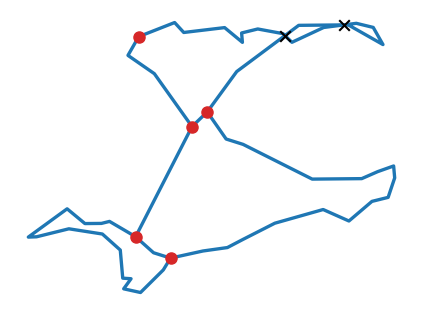

In [12]:
fig, ax = plt.subplots(figsize=(5.2, 4.4))
for arc in projection_inspection.arcs:
    ax.plot(*arc.line.xy, color=BLUE, linewidth=2.4)
for vertex in projection_inspection.vertices:
    ax.scatter(*vertex.point.xy, color=RED, s=64, zorder=3)
for crossing in projection_inspection.crossings:
    ax.scatter(*crossing.point.xy, marker="x", color="black", s=58, zorder=4)
ax.set_aspect("equal")
ax.axis("off")
plt.show()


In [13]:
print(f"rotation_angles = {tuple(round(a, 2) for a in projection_inspection.rotation_angles)}")
print(f"crossings = {projection_inspection.num_crossings}")
print(f"pd_code = {projection_inspection.pd_code}")
print("vertices =", [(v.id, v.key) for v in projection_inspection.vertices])
print(
    "crossing_points =",
    [(x.id, tuple(round(c, 3) for c in tuple(x.point.coords)[0])) for x in projection_inspection.crossings],
)
print(
    "arcs =",
    [(arc.id, arc.start_type, arc.start_id, arc.end_type, arc.end_id) for arc in projection_inspection.arcs],
)


rotation_angles = (-84.98, 81.01, 0.0)
crossings = 2
pd_code = V[1,0,2];V[8,1,7];V[7,6];V[9,0,10];V[10,8,9];X[2,5,3,6]
vertices = [(0, 0), (1, 1), (2, 2), (3, 3), (4, 5)]
crossing_points = [(0, (0.941, 1.145)), (1, (1.575, 1.26))]
arcs = [(0, 'v', 0, 'v', 3), (1, 'v', 0, 'v', 1), (2, 'v', 0, 'x', 0), (3, 'x', 0, 'x', 1), (4, 'x', 1, 'x', 1), (5, 'x', 1, 'x', 0), (6, 'x', 0, 'v', 2), (7, 'v', 1, 'v', 2), (8, 'v', 1, 'v', 4), (9, 'v', 3, 'v', 4), (10, 'v', 3, 'v', 4)]


The inspection output is deliberately verbose.  It gives the user enough
information to debug the exact diagram used downstream: the selected rotation,
crossings, vertices, arcs, and PD-code string.  The graph sequence also shows
which cleanup operation changes the skeleton at each stage.


### 3.1 The Same Pipeline Through The High-Level Convenience Method

The previous cells expose the intermediate objects one by one.  When a user
only wants the standard simplified graph, the high-level method wraps the same
core operations: skeleton image to graph, leaf removal, chain collapse, and
edge smoothing.


In [14]:
standard_graph = ske.skeleton_graph(simplify=True, smooth_epsilon=2)
standard_graph_kspace = graph_indices_to_kspace(standard_graph, ske)

print("standard high-level graph =", (standard_graph_kspace.number_of_nodes(), standard_graph_kspace.number_of_edges()))
print("manual processed graph =", (processed_graph.number_of_nodes(), processed_graph.number_of_edges()))


standard high-level graph = (6, 9)
manual processed graph = (5, 7)


In [15]:
fig = plot_graph_kg(standard_graph_kspace)
fig.show()


Publication-grid exports with panel letters and compressed PDF/SVG/PNG output
are deliberately separate from this tutorial.  The reusable library objects are
the generated surface, mask, skeleton, graphs, projection, PD code, and
polynomial displayed above.


## 6. Mathematical Workflows: Yamada Engines And Catalogs

The library exposes complementary routes for crossing-free state evaluation:
the recursive deletion-contraction route and the Negami-polynomial state-sum
route.  For small examples, the notebook compares them directly.  After that,
the same section treats Yamada computation as a mathematical graph-family
workflow: build a named graph, plot it with loops and edge multiplicities
visible, and record both `Upsilon(G;Y)` and its sigma form.


In [16]:
negami = compute_yamada_polynomial(
    processed_graph,
    Y,
    rotation_angles=projection_inspection.rotation_angles,
    method="negami",
    n_jobs=1,
)
recursive = compute_yamada_polynomial(
    processed_graph,
    Y,
    rotation_angles=projection_inspection.rotation_angles,
    method="recursive",
    n_jobs=1,
)
print_upsilon("G_awesome_inspection, negami", negami)
print_upsilon("G_awesome_inspection, recursive", recursive)
print("same_result =", sp.expand(negami - recursive) == 0)


Upsilon(G_awesome_inspection, negami; Y) = -Y**6 - Y**5 - 3*Y**4 - 2*Y**3 - 3*Y**2 - Y - 1
Upsilon(G_awesome_inspection, recursive; Y) = -Y**6 - Y**5 - 3*Y**4 - 2*Y**3 - 3*Y**2 - Y - 1
same_result = True


In [17]:
from knotted_graph.core import ThetaGraph
from knotted_graph.invariants.yamada import compute_yamada_polynomial_recursive

for s in range(2, 8):
    theta = ThetaGraph(s)
    upsilon = compute_yamada_polynomial_recursive(theta, Y)
    print_upsilon(f"Theta_{s}", upsilon)


Upsilon(Theta_2; Y) = Y + 1 + 1/Y
Upsilon(Theta_3; Y) = -Y**2 - Y - 2 - 1/Y - 1/Y**2
Upsilon(Theta_4; Y) = Y**3 + 2*Y**2 + 5*Y + 5 + 5/Y + 2/Y**2 + Y**(-3)


Upsilon(Theta_5; Y) = -Y**4 - 3*Y**3 - 8*Y**2 - 11*Y - 14 - 11/Y - 8/Y**2 - 3/Y**3 - 1/Y**4


Upsilon(Theta_6; Y) = Y**5 + 4*Y**4 + 12*Y**3 + 22*Y**2 + 34*Y + 37 + 34/Y + 22/Y**2 + 12/Y**3 + 4/Y**4 + Y**(-5)


Upsilon(Theta_7; Y) = -Y**6 - 5*Y**5 - 17*Y**4 - 38*Y**3 - 68*Y**2 - 92*Y - 104 - 92/Y - 68/Y**2 - 38/Y**3 - 17/Y**4 - 5/Y**5 - 1/Y**6


### Structured Graph Yamada Catalog

The mathematical catalog is a reusable part of the package.  It is useful when
the research question is about graph families themselves rather than a graph
extracted from a physical surface.  Each family has a builder, a layout, sample
parameters, and a short note.


In [18]:
from knotted_graph.applications.mathematical import (
    GRAPH_FAMILY_CATALOG,
    NOTEBOOK_YAMADA_EXAMPLES,
    build_graph_case,
    graph_summary,
    plot_structured_multigraph,
)
from knotted_graph.invariants.yamada import laurent_y_to_sigma_polynomial

sigma = sp.Symbol("sigma")

for family_name, spec in GRAPH_FAMILY_CATALOG.items():
    print(f"{family_name:24s} sample_args={spec.sample_args}  {spec.note}")


bouquet                  sample_args=(4,)  single-vertex loop bouquet
theta                    sample_args=(5,)  parallel-edge theta family
periodic_theta           sample_args=(4,)  theta strands with midpoint cycle
sierpinski               sample_args=(3, 2)  recursive S(n,t) family
complete_graph           sample_args=(4,)  complete graph K_n
complete_bipartite       sample_args=(2, 3)  bipartite graph K_{m,n}
complete_multipartite    sample_args=(2, 1, 1)  multipartite graph with arbitrary part sizes
fan                      sample_args=(5,)  hub joined to a path
wheel                    sample_args=(5,)  hub joined to a cycle
ladder                   sample_args=(4,)  two rails connected by rungs
circular_ladder          sample_args=(3,)  circular ladder / prism graph
grid                     sample_args=(2, 3)  rectangular grid
cylinder                 sample_args=(2, 3)  grid periodic in one direction
hypercube                sample_args=(3,)  hypercube Q_d
friendship           

The next cell generates the displayed catalog figure directly from the package
builders.  Parallel edges are curved apart, loops are drawn as visible loops,
and node labels are numeric aliases so the figure remains readable.


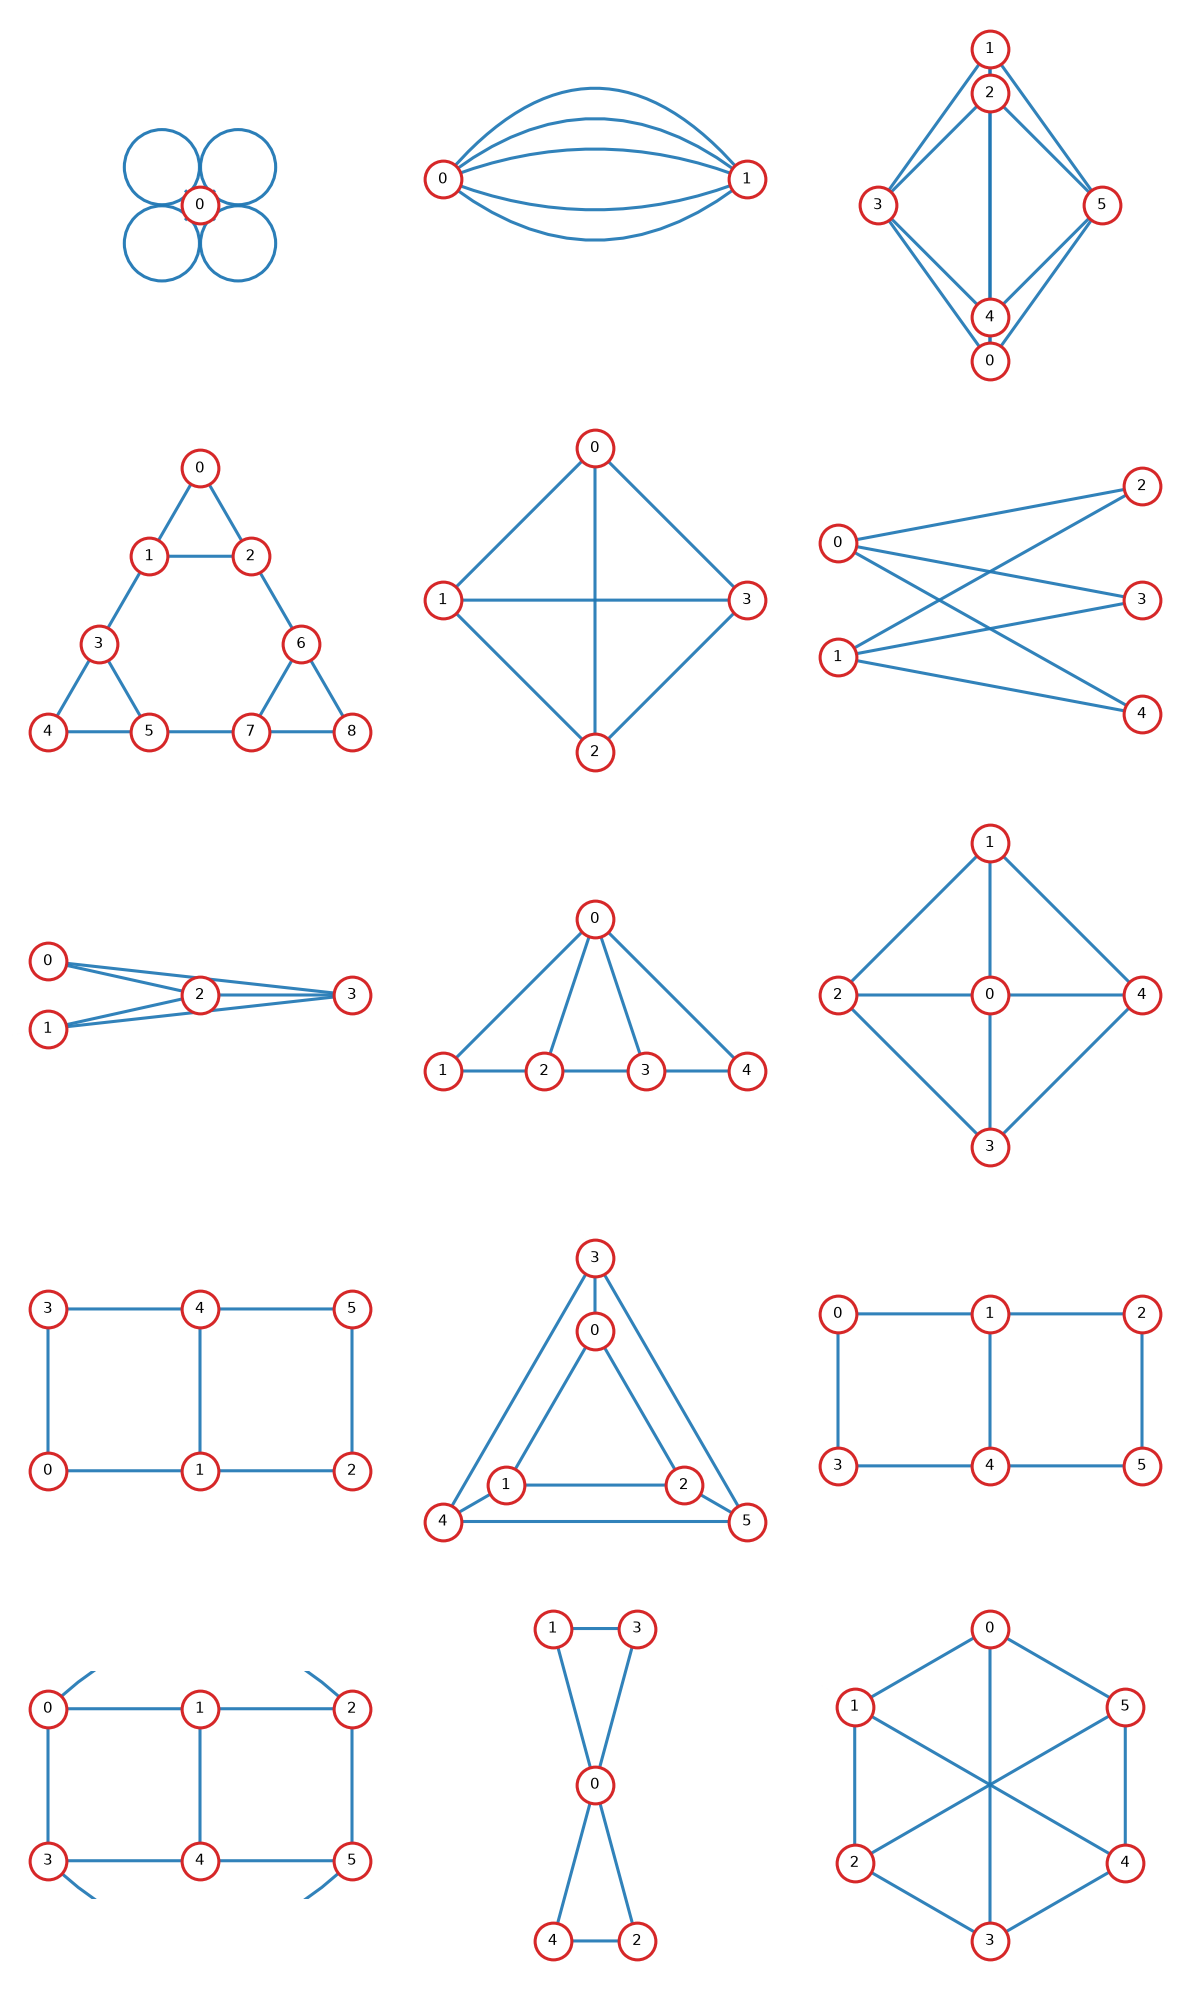

panel 1: Bouquet with 4 loops  {'nodes': 1, 'edges': 4, 'loops': 4, 'max_multiplicity': 4}
Upsilon(Bouquet with 4 loops; Y) = -Y**4 - 4*Y**3 - 10*Y**2 - 16*Y - 19 - 16/Y - 10/Y**2 - 4/Y**3 - 1/Y**4
Upsilon_sigma(Bouquet with 4 loops; sigma) = -sigma**4

panel 2: Theta graph with 5 parallel edges  {'nodes': 2, 'edges': 5, 'loops': 0, 'max_multiplicity': 5}
Upsilon(Theta graph with 5 parallel edges; Y) = -Y**4 - 3*Y**3 - 8*Y**2 - 11*Y - 14 - 11/Y - 8/Y**2 - 3/Y**3 - 1/Y**4
Upsilon_sigma(Theta graph with 5 parallel edges; sigma) = -sigma**4 + sigma**3 - sigma**2 + sigma

panel 3: Periodic theta graph with 4 strands  {'nodes': 6, 'edges': 12, 'loops': 0, 'max_multiplicity': 1}
Upsilon(Periodic theta graph with 4 strands; Y) = Y**7 + 2*Y**6 + 13*Y**5 + 18*Y**4 + 60*Y**3 + 64*Y**2 + 125*Y + 97 + 125/Y + 64/Y**2 + 60/Y**3 + 18/Y**4 + 13/Y**5 + 2/Y**6 + Y**(-7)
Upsilon_sigma(Periodic theta graph with 4 strands; sigma) = sigma**7 - 5*sigma**6 + 15*sigma**5 - 29*sigma**4 + 40*sigma**3 - 32*sigma

In [19]:
import matplotlib.pyplot as plt

catalog_results = {}
cols = 3
rows = math.ceil(len(NOTEBOOK_YAMADA_EXAMPLES) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = np.asarray(axes).reshape(-1)

for ax, (family_name, args, label) in zip(axes, NOTEBOOK_YAMADA_EXAMPLES):
    graph, pos = build_graph_case(family_name, *args)
    plot_structured_multigraph(
        graph,
        pos,
        family_name=family_name,
        family_args=args,
        ax=ax,
        show=False,
    )
    yamada_y = sp.expand(compute_yamada_polynomial_recursive(graph, Y))
    yamada_sigma = laurent_y_to_sigma_polynomial(yamada_y, Y, sigma).as_expr()
    catalog_results[label] = {
        "summary": graph_summary(graph),
        "Y": yamada_y,
        "sigma": sp.expand(yamada_sigma),
    }

for ax in axes[len(NOTEBOOK_YAMADA_EXAMPLES):]:
    ax.set_axis_off()

plt.tight_layout()
plt.show()

for panel_index, label in enumerate(catalog_results, start=1):
    result = catalog_results[label]
    print(f"panel {panel_index}: {label}  {result['summary']}")
    print_upsilon(label, result["Y"])
    print(f"Upsilon_sigma({label}; sigma) = {result['sigma']}")
    print()


For a single-family study, users can call the same builder with different
parameters.  This cell treats the cylinder family as a compact example of
scanning a parameterized graph family.


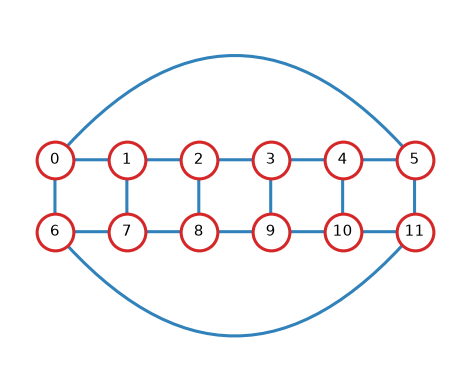

Cylinder(2,3): {'nodes': 6, 'edges': 9, 'loops': 0, 'max_multiplicity': 1}
Upsilon(Cylinder(2,3); Y) = -Y**4 + Y**3 - 3*Y**2 + 2*Y - 4 + 2/Y - 3/Y**2 + Y**(-3) - 1/Y**4
Upsilon_sigma(Cylinder(2,3); sigma) = -sigma**4 + 5*sigma**3 - 8*sigma**2 + 4*sigma

Cylinder(2,4): {'nodes': 8, 'edges': 12, 'loops': 0, 'max_multiplicity': 1}
Upsilon(Cylinder(2,4); Y) = Y**5 - 2*Y**4 + 7*Y**3 - 5*Y**2 + 14*Y - 6 + 14/Y - 5/Y**2 + 7/Y**3 - 2/Y**4 + Y**(-5)
Upsilon_sigma(Cylinder(2,4); sigma) = sigma**5 - 7*sigma**4 + 20*sigma**3 - 25*sigma**2 + 11*sigma

Cylinder(2,5): {'nodes': 10, 'edges': 15, 'loops': 0, 'max_multiplicity': 1}
Upsilon(Cylinder(2,5); Y) = -Y**6 + 3*Y**5 - 11*Y**4 + 15*Y**3 - 29*Y**2 + 27*Y - 38 + 27/Y - 29/Y**2 + 15/Y**3 - 11/Y**4 + 3/Y**5 - 1/Y**6
Upsilon_sigma(Cylinder(2,5); sigma) = -sigma**6 + 9*sigma**5 - 35*sigma**4 + 70*sigma**3 - 69*sigma**2 + 26*sigma

Cylinder(2,6): {'nodes': 12, 'edges': 18, 'loops': 0, 'max_multiplicity': 1}
Upsilon(Cylinder(2,6); Y) = Y**7 - 4*Y**6 + 16

In [20]:
cylinder_scan = []
for cols in range(3, 7):
    graph, pos = build_graph_case("cylinder", 2, cols)
    yamada_y = sp.expand(compute_yamada_polynomial_recursive(graph, Y))
    yamada_sigma = laurent_y_to_sigma_polynomial(yamada_y, Y, sigma).as_expr()
    cylinder_scan.append((cols, graph_summary(graph), yamada_y, sp.expand(yamada_sigma)))

graph, pos = build_graph_case("cylinder", 2, 6)
plot_structured_multigraph(
    graph,
    pos,
    family_name="cylinder",
    family_args=(2, 6),
)

for cols, summary, yamada_y, yamada_sigma in cylinder_scan:
    label = f"Cylinder(2,{cols})"
    print(f"{label}: {summary}")
    print_upsilon(label, yamada_y)
    print(f"Upsilon_sigma({label}; sigma) = {yamada_sigma}")
    print()


In [21]:
import csv

dataset_path = DOC_ROOT / "assets/data/structured_graph_yamada_dataset.csv"
with dataset_path.open(newline="") as handle:
    rows = list(csv.DictReader(handle))

print(f"stored structured rows = {len(rows)}")
for row in rows[:12]:
    print(f"Upsilon({row['graph_name']}{row['varying_params']}; Y) = {row['yamada']}")


stored structured rows = 89
Upsilon(periodic_theta(1,); Y) = 0
Upsilon(periodic_theta(2,); Y) = Y**3 + 2*Y**2 + 5*Y + 5 + 5/Y + 2/Y**2 + Y**(-3)
Upsilon(periodic_theta(3,); Y) = Y**5 + Y**4 + 7*Y**3 + 5*Y**2 + 15*Y + 8 + 15/Y + 5/Y**2 + 7/Y**3 + Y**(-4) + Y**(-5)
Upsilon(periodic_theta(4,); Y) = Y**7 + 2*Y**6 + 13*Y**5 + 18*Y**4 + 60*Y**3 + 64*Y**2 + 125*Y + 97 + 125/Y + 64/Y**2 + 60/Y**3 + 18/Y**4 + 13/Y**5 + 2/Y**6 + Y**(-7)
Upsilon(periodic_theta(5,); Y) = Y**9 + 3*Y**8 + 18*Y**7 + 36*Y**6 + 118*Y**5 + 167*Y**4 + 371*Y**3 + 396*Y**2 + 638*Y + 524 + 638/Y + 396/Y**2 + 371/Y**3 + 167/Y**4 + 118/Y**5 + 36/Y**6 + 18/Y**7 + 3/Y**8 + Y**(-9)
Upsilon(periodic_theta(6,); Y) = Y**11 + 4*Y**10 + 24*Y**9 + 64*Y**8 + 214*Y**7 + 416*Y**6 + 982*Y**5 + 1462*Y**4 + 2607*Y**3 + 3052*Y**2 + 4208*Y + 3893 + 4208/Y + 3052/Y**2 + 2607/Y**3 + 1462/Y**4 + 982/Y**5 + 416/Y**6 + 214/Y**7 + 64/Y**8 + 24/Y**9 + 4/Y**10 + Y**(-11)
Upsilon(periodic_theta(7,); Y) = Y**13 + 5*Y**12 + 31*Y**11 + 101*Y**10 + 355*Y*

The stored table remains useful as a reproducibility artifact, but the cells
above show the executable workflow: choose the family, build the graph, inspect
the figure, and compute the invariant in the notation of the paper.
